# UMAP from scratch — learn the recipe, then investigate why M2 OOD looks scattered

**Goal of this notebook**

1. Strip away the cosmetics from `presentation_preparation.ipynb` and learn the *minimum* recipe to build a UMAP: what inputs are needed, which functions are called, and what each step does.
2. Reproduce the M2 atlas UMAP in plain form so you can see the same n=248 "actual human OOD" cells the paper figure shows.
3. Use the same UMAP coordinates to **diagnose** the scattered-tails distribution: color the OOD cells by `cell_type_ontology_term_id`, `tissue`, and `donor_id` to find out where the heterogeneity comes from.
4. Try a side-by-side experiment where the OOD cells are *included* when fitting the UMAP (instead of being kNN-projected onto a UMAP fit only on training cells). This is the single biggest cosmetic change that makes the human OOD population look like a real cluster instead of a smear.

**Minimum inputs for any single-cell UMAP**

- A 2D expression matrix `X` of shape `(n_cells, n_features)`. Each row is a cell, each column is a gene (or HVG, or residual, etc.). Values must be on a sensible numeric scale (log-normalized counts, Pearson residuals, etc.) — UMAP does not normalize for you.
- Cell-level metadata in `adata.obs` so you can color points (cell type, species, tissue, donor, ...). Metadata is for coloring only; it never affects the geometry.
- A reduced-dimension representation, typically PCA (`sc.pp.pca`), because computing neighbors in 1000-dim space is slow and noisy.
- A nearest-neighbor graph on the PCA representation (`sc.pp.neighbors`).
- The UMAP optimizer that lays out that graph in 2D (`sc.tl.umap`).
- A plotting call (`sc.pl.umap` or plain `plt.scatter` on `adata.obsm['X_umap']`).

Everything else (titles, legends, custom palettes, marker overlays, multi-panel grids) is cosmetic.

**Where this notebook lives**

Saved next to `presentation_preparation.ipynb`. Outputs (PNGs) go to `umap_learn_outputs/` to keep the polished-figure folder untouched.

In [14]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad
import scanpy as sc
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors

REPO = Path("/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT")
CELL_GPU = REPO / "cellot/cellot_gpu"
RESULTS = CELL_GPU / "results"
OUT_DIR = REPO / "speciesOT/baseline/analysis/umap_learn_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Same Pearson HVG M2 file the paper figure uses
H5_PATH = CELL_GPU / "datasets/speciesot-human-mouse-hvg/hvg_pearson_residuals_m2_v07.h5ad"

# Same holdout the paper figure uses (M2 = non-classical + generic monocyte)
HOLDOUT_IDS = ["CL:0000875", "CL:0000576"]
CT_COL = "cell_type_ontology_term_id"

print("input file:", H5_PATH)
print("holdout ids:", HOLDOUT_IDS)
print("output dir:", OUT_DIR)

input file: /n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu/datasets/speciesot-human-mouse-hvg/hvg_pearson_residuals_m2_v07.h5ad
holdout ids: ['CL:0000875', 'CL:0000576']
output dir: /n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/speciesOT/baseline/analysis/umap_learn_outputs


## Step 1 — Load the AnnData and inspect what is inside

`AnnData` is just a container: `.X` is the cells × genes matrix, `.obs` is per-cell metadata, `.var` is per-gene metadata. UMAP only needs `.X` for geometry; everything else is for color/grouping.

In [15]:
raw = ad.read_h5ad(H5_PATH)
print("shape (n_cells, n_genes):", raw.shape)
print("obs columns:", list(raw.obs.columns))
print()
print(raw.obs.head())
print()
print("X dtype/scale check:")
x = raw.X if isinstance(raw.X, np.ndarray) else raw.X.toarray()
print("  dtype:", x.dtype, "  range:", x.min(), "to", x.max())
print("  this is Pearson residuals — values are not raw counts, they can be negative and")
print("  are already variance-stabilized. UMAP can ingest them directly.")

shape (n_cells, n_genes): (12990, 1000)
obs columns: ['cell_type', 'cell_type_ontology_term_id', 'condition', 'donor_id', 'species', 'tissue', 'tissue_ontology_term_id']

                                          cell_type  \
CGGGTCACATTGGGCC-1-14-1-0    non-classical monocyte   
10X_P7_9_TTTGGTTCACGAGAGT-1  non-classical monocyte   
10X_P7_9_GGAATAACATCCGCGA-1  non-classical monocyte   
GTTTCTATCTAGCACA-1-31-0-0    non-classical monocyte   
10X_P7_9_CATTATCCAGACGTAG-1  non-classical monocyte   

                            cell_type_ontology_term_id condition donor_id  \
CGGGTCACATTGGGCC-1-14-1-0                   CL:0000875     mouse   30-M-3   
10X_P7_9_TTTGGTTCACGAGAGT-1                 CL:0000875     mouse   3-F-57   
10X_P7_9_GGAATAACATCCGCGA-1                 CL:0000875     mouse   3-F-57   
GTTTCTATCTAGCACA-1-31-0-0                   CL:0000875     mouse  18-M-52   
10X_P7_9_CATTATCCAGACGTAG-1                 CL:0000875     mouse   3-F-57   

                            species

## Step 2 — Mark which cells are train / ood / ignore (same logic as the paper figure)

The paper figure builds the atlas from `split == "train"` cells and overlays `split == "ood"` cells. That `split` column is not stored in the H5AD; it is computed at runtime from two pieces of metadata:

1. `condition` — "mouse" or "human" (we add `transport` as a synonym: source / target).
2. `cell_type_ontology_term_id` — used to flag which cells are in the M2 holdout.

Inside each `condition` group, 80% of *non-holdout* cells go to `train`, 20% to `test`. Then holdout cells are flipped: 50% go to `ignore` (never seen by the model) and 50% to `ood` (the prediction target). This is the toggle-OOD recipe from CellOT.

In [16]:
# input an adata object, output the same anndat with one extra obs column called transport
# basically map condition to transport
def add_transport(a):
    out = a.copy()
    out.obs = out.obs.copy()
    out.obs["transport"] = out.obs["condition"].map({"mouse": "source", "human": "target"})
    return out

# return an anndata where every cell has been tagged with train/test/ignore/ood
# specifically in obs["split"]
def split_toggle_ood(a, holdout_ids, groupby="condition", key=CT_COL, random_state=0, test_size=0.2):
    # a pandas series, all values empty for now, object type so it can hold string
    split = pd.Series(index=a.obs_names, dtype=object)
    # stratify by species loop, loops twice, once for mouse, once for human
    for _, idx in a.obs.groupby(groupby, observed=False).groups.items():
        # idx is the species cell IDs (6495 mouse cells, 6495 human cells)
        tr, te = train_test_split(idx, random_state=random_state, test_size=test_size)
        split.loc[tr] = "train"
        split.loc[te] = "test"
    ood_ix = a.obs_names[a.obs[key].astype(str).isin(holdout_ids)]
    ignore_ix, ood_keep_ix = train_test_split(ood_ix, random_state=random_state, test_size=0.5)
    split.loc[ignore_ix] = "ignore"
    split.loc[ood_keep_ix] = "ood"
    out = a.copy()
    out.obs["split"] = split.astype("category")
    return out


d = add_transport(raw)
d = split_toggle_ood(d, HOLDOUT_IDS)
print(d.obs["split"].value_counts())
print()
print("holdout-OOD cells by species and ontology:")
mask = (d.obs["split"] == "ood") & d.obs[CT_COL].astype(str).isin(HOLDOUT_IDS)
print(pd.crosstab(d.obs.loc[mask, "transport"], d.obs.loc[mask, CT_COL].astype(str)))

split
train     9588
test      2384
ood        509
ignore     509
Name: count, dtype: int64

holdout-OOD cells by species and ontology:
cell_type_ontology_term_id  CL:0000576  CL:0000875
transport                                         
target                              45         203
source                              43         218


## Step 3 — Print the composition of the n=248 "actual human OOD" cells

This is the population the paper UMAP shows in red. We will print its tissue, ontology, and donor breakdown so you can match each "tail" you see in the UMAP back to a biological group.

In [17]:
ood_human = d[(d.obs["split"] == "ood") & (d.obs["transport"] == "target") & d.obs[CT_COL].astype(str).isin(HOLDOUT_IDS)].copy()
print("n actual human OOD:", ood_human.n_obs)
print()
print("by ontology id:")
print(ood_human.obs[CT_COL].astype(str).value_counts())
print()
print("by tissue:")
print(ood_human.obs["tissue"].astype(str).value_counts())
print()
print("by donor:")
print(ood_human.obs["donor_id"].astype(str).value_counts())
print()
print("tissue x ontology cross-tab (the heterogeneity in 2D):")
print(pd.crosstab(ood_human.obs["tissue"].astype(str), ood_human.obs[CT_COL].astype(str)))

n actual human OOD: 248

by ontology id:
cell_type_ontology_term_id
CL:0000875    203
CL:0000576     45
Name: count, dtype: int64

by tissue:
tissue
lung           203
bone marrow     43
heart            2
Name: count, dtype: int64

by donor:
donor_id
TSP2     152
TSP1      46
TSP14     20
TSP25     12
TSP21     12
TSP11      4
TSP27      1
TSP13      1
Name: count, dtype: int64

tissue x ontology cross-tab (the heterogeneity in 2D):
cell_type_ontology_term_id  CL:0000576  CL:0000875
tissue                                            
bone marrow                         43           0
heart                                2           0
lung                                 0         203


## Step 4 — Build the reference (training atlas) UMAP

Three lines do all the work. Everything in `presentation_preparation.ipynb` that looks complicated is just plotting on top of these three outputs.

In [18]:
# Here is 80/20 split, we operate on the training set
ref = d[d.obs["split"] == "train"].copy()
ref.X = ref.X if isinstance(ref.X, np.ndarray) else ref.X.toarray()
ref.X = ref.X.astype(np.float32)
print("training atlas shape:", ref.shape)

# For the PCA space, we use 50 PCs
n_pcs = int(min(50, ref.n_vars - 1, max(2, ref.n_obs - 1)))
sc.pp.pca(ref, n_comps=n_pcs)

# PCA followed by nearest neighbor
sc.pp.neighbors(ref, n_neighbors=15, n_pcs=n_pcs)

# Nearest Neighbor followed by a UMAP construction
sc.tl.umap(ref, min_dist=0.3, random_state=42)

print("X_pca shape:", ref.obsm["X_pca"].shape)
print("X_umap shape:", ref.obsm["X_umap"].shape)

training atlas shape: (9588, 1000)
X_pca shape: (9588, 50)
X_umap shape: (9588, 2)


## Step 5 — Plot the training atlas alone

Just `sc.pl.umap(adata, color=<obs column>)`. No styling tricks.

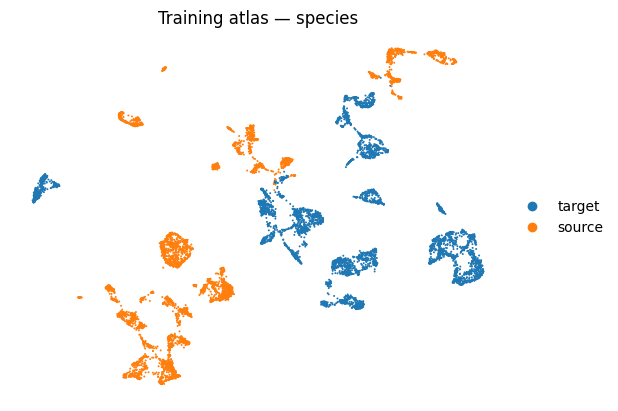

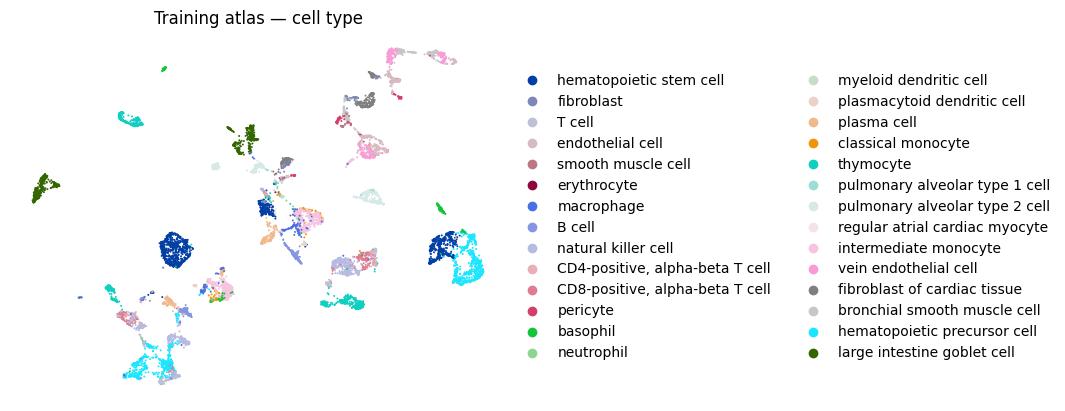

In [19]:
sc.pl.umap(ref, color="transport", title="Training atlas — species", s=8, frameon=False, show=True)
if "cell_type" in ref.obs.columns:
    sc.pl.umap(ref, color="cell_type", title="Training atlas — cell type", s=8, frameon=False, show=True)

## Step 6 — Project the OOD cells onto the atlas via kNN in PCA space

This is the same projection function used in `presentation_preparation.ipynb` and `06.3_scanpy_faceted_umap.ipynb`. The idea:

1. PCA was fit on the training atlas. PCA returns axes (`varm['PCs']`) and the training-mean used to center the data.
2. Center each new (OOD) cell by the *training* mean and multiply by the same PC axes — that puts the OOD cell in the same PCA frame as the atlas.
3. Find its k=10 nearest training cells in PCA space.
4. Compute its 2D UMAP position as a distance-weighted average of those 10 neighbors' UMAP coordinates.

**Important property:** this projection never lets the OOD cell land outside the convex hull of the training cells' UMAP. If a cell is biologically far from anything in the atlas, kNN still drags it onto the atlas's UMAP — which is one source of the "scattered tails" look. (This is a *property of the projection*, not a bug.) See Step 8 for an alternative.

In [20]:
def project_onto_ref_umap(X_new, ref_adata, n_neighbors=10):
    pcs = ref_adata.varm["PCs"]
    ref_pca = ref_adata.obsm["X_pca"]
    ref_umap = ref_adata.obsm["X_umap"]
    ref_mean = np.asarray(ref_adata.X.mean(axis=0)).ravel()
    X_new = np.asarray(X_new, dtype=np.float32)
    new_pca = (X_new - ref_mean) @ pcs
    k = min(n_neighbors, max(1, ref_pca.shape[0] - 1))
    nn = NearestNeighbors(n_neighbors=k, metric="euclidean").fit(ref_pca)
    dists, idxs = nn.kneighbors(new_pca)
    w = 1.0 / (dists + 1e-8)
    w = w / w.sum(axis=1, keepdims=True)
    return np.stack([(w[i, :, None] * ref_umap[idxs[i]]).sum(axis=0) for i in range(len(new_pca))])


X_ood_human = ood_human.X if isinstance(ood_human.X, np.ndarray) else ood_human.X.toarray()
X_ood_human = X_ood_human.astype(np.float32)
u_ood_human = project_onto_ref_umap(X_ood_human, ref)
print("OOD projected UMAP shape:", u_ood_human.shape)

OOD projected UMAP shape: (248, 2)


## Step 7 — Diagnose: the same OOD points colored three different ways

These three panels share the **same** UMAP coordinates — only the color changes. If the "tails" align cleanly with `tissue` or `donor_id`, that tells you the heterogeneity is biological/technical, not a UMAP artefact.

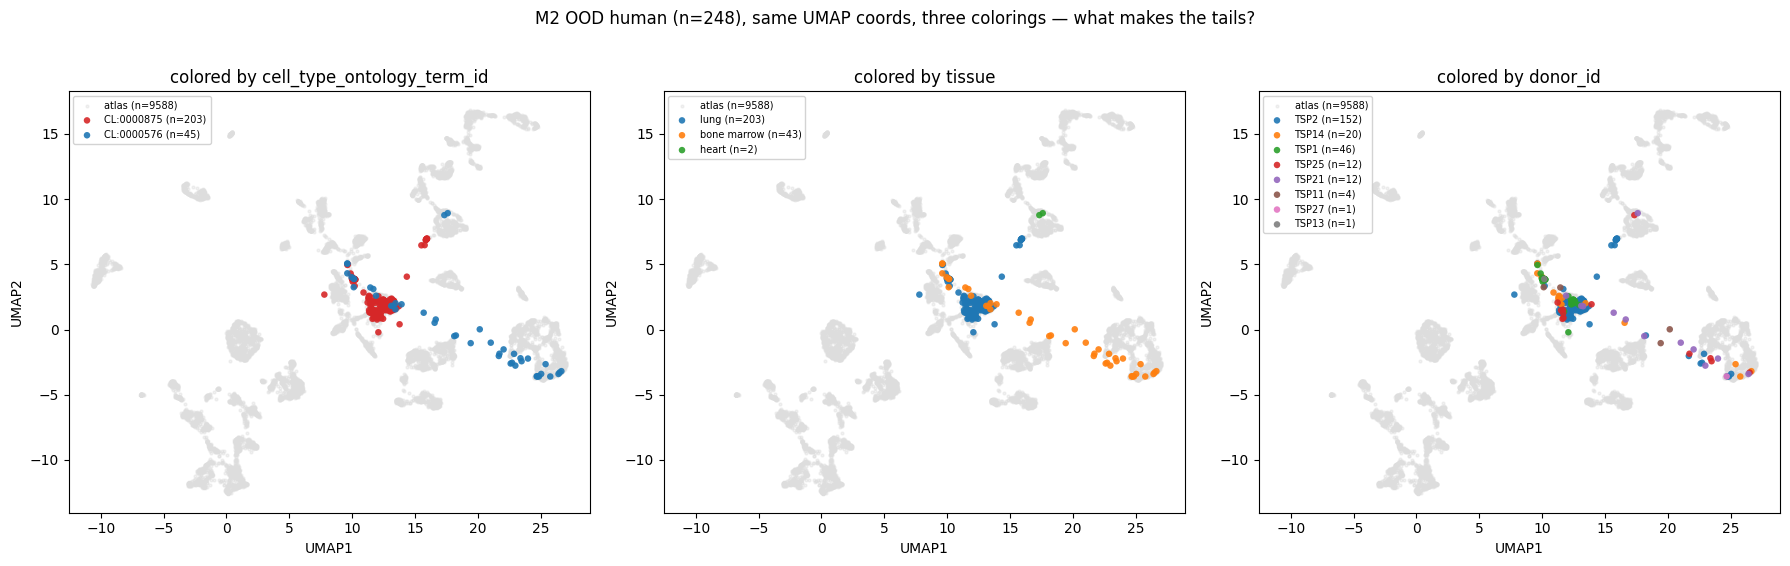

In [21]:
ur = ref.obsm["X_umap"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
color_specs = [
    (CT_COL, {"CL:0000875": "#d62728", "CL:0000576": "#1f77b4"}, "colored by cell_type_ontology_term_id"),
    ("tissue", None, "colored by tissue"),
    ("donor_id", None, "colored by donor_id"),
]
for ax, (col, palette, title) in zip(axes, color_specs):
    ax.scatter(ur[:, 0], ur[:, 1], s=4, c="#dddddd", alpha=0.4, rasterized=True, label=f"atlas (n={ref.n_obs})")
    vals = ood_human.obs[col].astype(str).values
    cats = list(pd.unique(vals))
    if palette is None:
        cmap = plt.get_cmap("tab10" if len(cats) <= 10 else "tab20")
        palette = {c: cmap(i % cmap.N) for i, c in enumerate(cats)}
    for c in cats:
        m = vals == c
        ax.scatter(u_ood_human[m, 0], u_ood_human[m, 1], s=22, c=[palette[c]], edgecolors="none", alpha=0.9, label=f"{c} (n={int(m.sum())})")
    ax.set_title(title)
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")
    ax.legend(fontsize=7, loc="best", framealpha=0.85)
fig.suptitle("M2 OOD human (n=248), same UMAP coords, three colorings — what makes the tails?", y=1.02)
fig.tight_layout()
fig.savefig(OUT_DIR / "m2_ood_human_diagnostic_by_metadata.png", dpi=200, bbox_inches="tight")
plt.show()

**What you should see**

- The big tight cluster is the 203 lung non-classical monocytes (CL:0000875, tissue=lung, donor TSP2 dominates).
- The off-cluster tails should be enriched for tissue=`bone marrow` and ontology=CL:0000576 ("monocyte" generic). Those are biologically a *different* population — bone-marrow circulating/developing monocytes — that the curators labeled with the parent term because they did not sub-type them.
- So the M2 holdout is two biological populations under one label set, and the UMAP is honestly reporting that.

## Step 8 — Cosmetic alternative: include the OOD cells when *fitting* the UMAP

The paper figure must use a kNN projection because the model predictions for cells that were never in training have to land somewhere — projection is the principled way to do that. But if your goal is purely to *visualize* whether the actual human OOD cells form a sensible cluster, you can include them in PCA + neighbors + UMAP fitting. The cluster usually looks tighter because UMAP is allowed to make space for them.

This is a *visualization-only* change. Do not use this version when comparing to scGen / IMPACT predictions — those need the projection method.

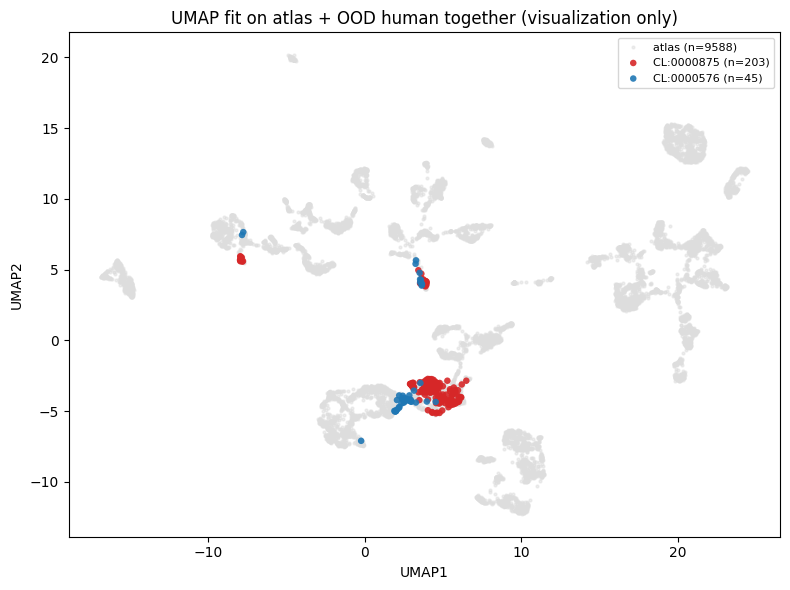

In [22]:
joint = ad.concat([ref, ood_human], join="inner", label="role", keys=["atlas", "ood_human"])
joint.X = joint.X if isinstance(joint.X, np.ndarray) else joint.X.toarray()
joint.X = joint.X.astype(np.float32)

n_pcs_j = int(min(50, joint.n_vars - 1, max(2, joint.n_obs - 1)))
sc.pp.pca(joint, n_comps=n_pcs_j)
sc.pp.neighbors(joint, n_neighbors=15, n_pcs=n_pcs_j)
sc.tl.umap(joint, min_dist=0.3, random_state=42)

uj = joint.obsm["X_umap"]
is_ood = (joint.obs["role"].astype(str) == "ood_human").values

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(uj[~is_ood, 0], uj[~is_ood, 1], s=4, c="#dddddd", alpha=0.5, rasterized=True, label=f"atlas (n={(~is_ood).sum()})")
ood_obs = joint.obs.loc[is_ood]
for cid, color in [("CL:0000875", "#d62728"), ("CL:0000576", "#1f77b4")]:
    m = (ood_obs[CT_COL].astype(str) == cid).values
    ax.scatter(uj[is_ood][m, 0], uj[is_ood][m, 1], s=22, c=color, edgecolors="none", alpha=0.9, label=f"{cid} (n={int(m.sum())})")
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_title("UMAP fit on atlas + OOD human together (visualization only)")
ax.legend(loc="best", fontsize=8)
fig.tight_layout()
fig.savefig(OUT_DIR / "m2_ood_human_joint_umap.png", dpi=200, bbox_inches="tight")
plt.show()

## What you have learned

- A UMAP needs (a) a numeric `cells × features` matrix, (b) PCA, (c) a neighbors graph, (d) the UMAP layout, (e) metadata for color. `sc.pp.pca` → `sc.pp.neighbors` → `sc.tl.umap` → `sc.pl.umap` is the entire pipeline.
- The "scattered tails" in the M2 actual-human-OOD UMAP are not a pipeline bug. The n=248 holdout is itself heterogeneous: ~203 lung non-classical monocytes (CL:0000875) + ~43 bone-marrow generic monocytes (CL:0000576) + ~2 heart cells, plus heavy donor imbalance (TSP2 is 60% of the lung cells).
- The kNN-projection step also amplifies the spread: holdout cells whose biology is far from the training atlas are forced to land near *some* atlas neighbor, which can stretch them into long tails.
- The cleanest fix for the *visualization* concern is to include the OOD cells when fitting the UMAP (Step 8). The cleanest fix for the *task design* concern is to ask whether the holdout should mix tissues at all — that is a methodology question, not a code question, and it ties back to your mentor's `M2 is the right task` choice.

In [23]:
# Holding out just non-classical monocytes
# They originate from lung
# We don't care about generic monocytes anymore, they originate from bone marrow, distant in UMAP
# M1 leaves out non-classical monocytes
# Same Pearson HVG M1 file the paper figure uses

In [24]:
HOLDOUT_IDS_M1 = ["CL:0000875"]   # M1: non-classical monocyte ONLY (no generic CL:0000576)

d_m1 = add_transport(raw)                                  # same file as M2
d_m1 = split_toggle_ood(d_m1, HOLDOUT_IDS_M1)              # ← key change: M1 holdout list
print(d_m1.obs["split"].value_counts())
print()
print("M1 holdout-OOD cells by species and ontology:")
mask = (d_m1.obs["split"] == "ood") & d_m1.obs[CT_COL].astype(str).isin(HOLDOUT_IDS_M1)
print(pd.crosstab(d_m1.obs.loc[mask, "transport"], d_m1.obs.loc[mask, CT_COL].astype(str)))

split
train     9720
test      2418
ood        426
ignore     426
Name: count, dtype: int64

M1 holdout-OOD cells by species and ontology:
cell_type_ontology_term_id  CL:0000875
transport                             
target                             207
source                             219


## Step 4–7 (M1 version) — same recipe, single-ontology holdout

Reuse the same M2 Pearson HVG file (`raw`) with `HOLDOUT_IDS_M1 = ["CL:0000875"]`. This is the proxy approach explained in the M1 setup section: cells are identical across HVG flavor files, and ~93% of the 1000 HVG genes overlap, so the geometry is faithful enough to confirm the M1-vs-M2 contrast without regenerating a proper M1 file.

We build a *separate* M1 training atlas because its training set differs slightly from M2 — M1 keeps the 166 generic monocyte cells (83 mouse + 83 human) that M2 excludes. Then project the n=207 actual-human-OOD population onto it via kNN in PCA space, and run the same 3-panel diagnostic from Step 7.

Visual prediction: M1 OOD should land as one tight lung cluster (single tissue, single ontology, donor-imbalanced toward TSP2). No bone-marrow tail, no heart outliers.

M1 training atlas shape: (9720, 1000)

M1 actual-human-OOD: n = 207
  by ontology: {'CL:0000875': np.int64(207)}
  by tissue  : {'lung': np.int64(207)}
  by donor   : {'TSP2': np.int64(146), 'TSP1': np.int64(37), 'TSP14': np.int64(18), 'TSP25': np.int64(6)}

Projected OOD onto M1 atlas: (207, 2)


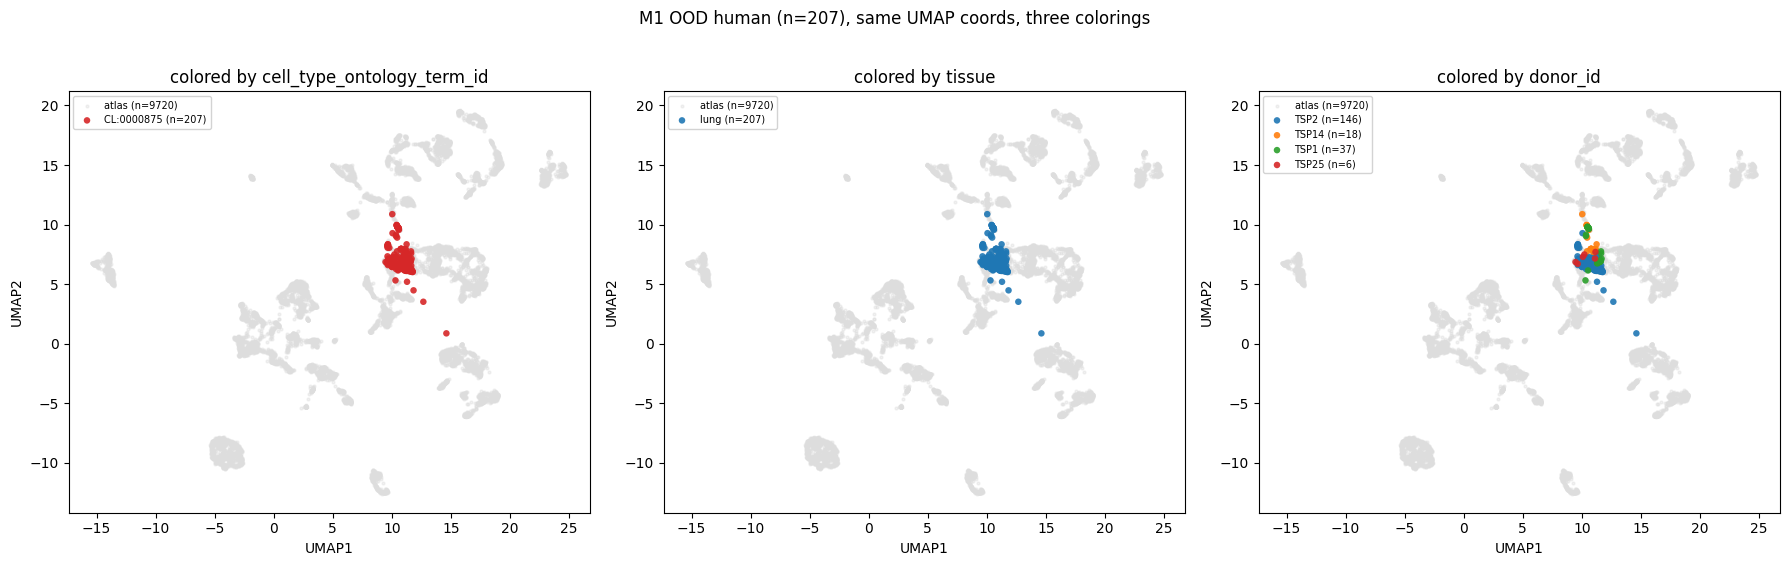

In [25]:
# === Step 4 (M1) — build the M1 training atlas ===
ref_m1 = d_m1[d_m1.obs["split"] == "train"].copy()
ref_m1.X = ref_m1.X if isinstance(ref_m1.X, np.ndarray) else ref_m1.X.toarray()
ref_m1.X = ref_m1.X.astype(np.float32)
print("M1 training atlas shape:", ref_m1.shape)

n_pcs_m1 = int(min(50, ref_m1.n_vars - 1, max(2, ref_m1.n_obs - 1)))
sc.pp.pca(ref_m1, n_comps=n_pcs_m1)
sc.pp.neighbors(ref_m1, n_neighbors=15, n_pcs=n_pcs_m1)
sc.tl.umap(ref_m1, min_dist=0.3, random_state=42)

# === Step 3 (M1) — extract the actual-human-OOD population ===
ood_human_m1 = d_m1[
    (d_m1.obs["split"] == "ood")
    & (d_m1.obs["transport"] == "target")
    & d_m1.obs[CT_COL].astype(str).isin(HOLDOUT_IDS_M1)
].copy()
print("\nM1 actual-human-OOD: n =", ood_human_m1.n_obs)
print("  by ontology:", dict(ood_human_m1.obs[CT_COL].astype(str).value_counts()))
print("  by tissue  :", dict(ood_human_m1.obs["tissue"].astype(str).value_counts()))
print("  by donor   :", dict(ood_human_m1.obs["donor_id"].astype(str).value_counts()))

# === Step 6 (M1) — project OOD onto M1 atlas via kNN in PCA space ===
X_ood_human_m1 = ood_human_m1.X if isinstance(ood_human_m1.X, np.ndarray) else ood_human_m1.X.toarray()
X_ood_human_m1 = X_ood_human_m1.astype(np.float32)
u_ood_human_m1 = project_onto_ref_umap(X_ood_human_m1, ref_m1)
print("\nProjected OOD onto M1 atlas:", u_ood_human_m1.shape)

# === Step 7 (M1) — 3-panel diagnostic: same OOD coords, three colorings ===
ur_m1 = ref_m1.obsm["X_umap"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
color_specs_m1 = [
    (CT_COL, {"CL:0000875": "#d62728"}, "colored by cell_type_ontology_term_id"),
    ("tissue", None, "colored by tissue"),
    ("donor_id", None, "colored by donor_id"),
]
for ax, (col, palette, title) in zip(axes, color_specs_m1):
    ax.scatter(ur_m1[:, 0], ur_m1[:, 1], s=4, c="#dddddd", alpha=0.4, rasterized=True, label=f"atlas (n={ref_m1.n_obs})")
    vals = ood_human_m1.obs[col].astype(str).values
    cats = list(pd.unique(vals))
    if palette is None:
        cmap = plt.get_cmap("tab10" if len(cats) <= 10 else "tab20")
        palette = {c: cmap(i % cmap.N) for i, c in enumerate(cats)}
    for c in cats:
        m = vals == c
        ax.scatter(u_ood_human_m1[m, 0], u_ood_human_m1[m, 1], s=22, c=[palette[c]], edgecolors="none", alpha=0.9, label=f"{c} (n={int(m.sum())})")
    ax.set_title(title)
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")
    ax.legend(fontsize=7, loc="best", framealpha=0.85)
fig.suptitle(f"M1 OOD human (n={ood_human_m1.n_obs}), same UMAP coords, three colorings", y=1.02)
fig.tight_layout()
fig.savefig(OUT_DIR / "m1_ood_human_diagnostic_by_metadata.png", dpi=200, bbox_inches="tight")
plt.show()

## Side-by-side: M1 vs M2 OOD on their respective atlases

Two panels, each plotting the actual-human-OOD population (red = lung non-classical, orange = bone-marrow generic, green = heart generic) on top of its training atlas (gray). The atlases have different UMAP coordinate frames, so absolute positions are not comparable across panels — only the *shape* of the OOD distribution matters: single tight cluster (M1) vs multi-tissue scatter (M2).

This is the money slide for the leakage-vs-task-difficulty trade-off.

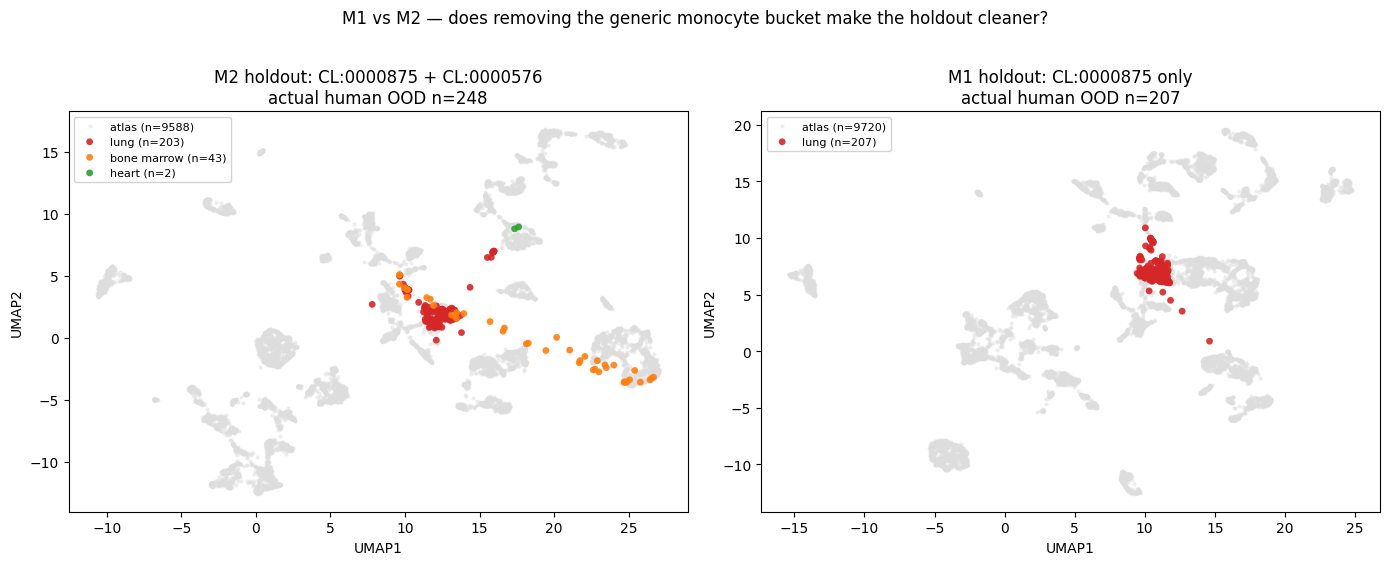

In [26]:
TISSUE_PALETTE = {"lung": "#d62728", "bone marrow": "#ff7f0e", "heart": "#2ca02c"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
panels = [
    ("M2 holdout: CL:0000875 + CL:0000576",
     ref, ood_human, u_ood_human, axes[0]),
    ("M1 holdout: CL:0000875 only",
     ref_m1, ood_human_m1, u_ood_human_m1, axes[1]),
]
for title, atlas, ood_a, u_ood, ax in panels:
    ax.scatter(atlas.obsm["X_umap"][:, 0], atlas.obsm["X_umap"][:, 1],
               s=4, c="#dddddd", alpha=0.4, rasterized=True,
               label=f"atlas (n={atlas.n_obs})")
    vals = ood_a.obs["tissue"].astype(str).values
    for c in pd.unique(vals):
        m = vals == c
        color = TISSUE_PALETTE.get(c, "#888888")
        ax.scatter(u_ood[m, 0], u_ood[m, 1], s=24, c=color,
                   edgecolors="none", alpha=0.9,
                   label=f"{c} (n={int(m.sum())})")
    ax.set_title(f"{title}\nactual human OOD n={len(u_ood)}")
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")
    ax.legend(fontsize=8, loc="best", framealpha=0.85)
fig.suptitle("M1 vs M2 — does removing the generic monocyte bucket make the holdout cleaner?", y=1.02)
fig.tight_layout()
fig.savefig(OUT_DIR / "m1_vs_m2_ood_by_tissue_sidebyside.png", dpi=200, bbox_inches="tight")
plt.show()